# Week 12 Homework：ARIA v8.0 — The Classification Engine

**研究區：秀林 / 太魯閣（Xiulin / Taroko）**  
**資料：Sentinel-2 L2A + SCL 雲遮罩 + SWCB 新生崩塌地 KML**  
**方法：K-means 非監督式分類、Random Forest 監督式分類、Confusion Matrix、SWCB 外部驗證、AI 報告**

本 notebook 已依作業要求整理為可直接在 Colab 執行的版本。執行後會輸出：

- `kmeans_classification.png`
- `rf_classification.png`
- `confusion_matrix.png`
- `swcb_overlay.png`
- `class_area_stats.csv`
- `Week12_ARIA_v8_Report.md`

> 注意：Random Forest 的訓練樣本以「自動光譜種子樣本」作為可執行版本。正式繳交時，建議改用 Google Earth / KMZ ROI 手動樣本，以符合課堂建議並提升分類可信度。


In [1]:
# =============================================================================
# 0. 安裝與匯入套件
# =============================================================================
# 在 Colab 第一次執行時如缺少套件，請取消下一行註解：
!pip -q install pystac-client planetary-computer stackstac geopandas rasterio shapely gdown google-generativeai

import os
import glob
import json
import zipfile
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score,
    ConfusionMatrixDisplay,
)
from scipy.ndimage import median_filter

import pystac_client
import planetary_computer as pc
import stackstac

import geopandas as gpd
from shapely.geometry import Polygon, box
from rasterio.features import rasterize
from affine import Affine
from pyproj import Transformer

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

# 中文字型：Colab 可安裝 Noto CJK；Windows 可用 Microsoft JhengHei
try:
    import matplotlib.font_manager as fm
    candidates = ["Microsoft JhengHei", "Noto Sans CJK TC", "PingFang TC", "Heiti TC", "SimHei"]
    available = {f.name for f in fm.fontManager.ttflist}
    found = [f for f in candidates if f in available]
    if found:
        plt.rcParams["font.sans-serif"] = found + ["DejaVu Sans"]
except Exception:
    pass

OUT_DIR = Path("week12_outputs")
OUT_DIR.mkdir(exist_ok=True)
print("環境設定完成。輸出資料夾：", OUT_DIR.resolve())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.9 MB/s eta 0:00:00
環境設定完成。輸出資料夾： /content/week12_outputs


## 1. STAC API 影像搜尋與前處理

本作業使用秀林 / 太魯閣研究區，BBOX 如下：

- West：121.40
- South：24.10
- East：121.80
- North：24.25

此範圍涵蓋中央山脈東側、太魯閣周邊與太平洋海域，因此可以同時取得森林、裸地 / 崩塌與水體樣本。


In [2]:
# =============================================================================
# 1. STAC API 搜尋 Sentinel-2 L2A 震後影像
# =============================================================================
TAROKO_BBOX = [121.40, 24.10, 121.80, 24.25]
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
BANDS_ALL = BANDS + ["SCL"]
BAND_NAMES = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

CLASS_NAMES = ["Water", "Forest", "Cropland", "Bare/Landslide", "Built-up"]
CLASS_NAMES_ZH = ["水體", "森林", "農田", "裸地/崩塌", "建物/都市"]
N_CLASSES = len(CLASS_NAMES)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

search_configs = [
    ("2024-04-15/2024-05-31", 20, "Phase 1：震後 2 個月，雲量 < 20%"),
    ("2024-04-03/2024-08-31", 30, "Phase 2：震後 5 個月，雲量 < 30%"),
    ("2024-04-03/2024-12-31", 50, "Phase 3：震後全年，雲量 < 50%"),
]

items = []
for dt_range, max_cc, desc in search_configs:
    print(f"嘗試 {desc}...")
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=TAROKO_BBOX,
        datetime=dt_range,
        query={"eo:cloud_cover": {"lt": max_cc}},
    )
    items = list(search.items())
    print(f"  → 找到 {len(items)} 景影像")
    if len(items) > 0:
        break

if not items:
    raise RuntimeError("找不到符合條件的 Sentinel-2 影像，請檢查網路或放寬搜尋條件。")

items_sorted = sorted(items, key=lambda x: x.properties["eo:cloud_cover"])
best_item = items_sorted[0]

print("\n=== 選取影像 ===")
print("ID：", best_item.id)
print("日期：", best_item.datetime.strftime("%Y-%m-%d %H:%M:%S"))
print("雲量：", f"{best_item.properties['eo:cloud_cover']:.1f}%")
print("BBOX：", TAROKO_BBOX)


嘗試 Phase 1：震後 2 個月，雲量 < 20%...
  → 找到 0 景影像
嘗試 Phase 2：震後 5 個月，雲量 < 30%...
  → 找到 10 景影像

=== 選取影像 ===
ID： S2A_MSIL2A_20240827T022531_R046_T51QUG_20240827T053853
日期： 2024-08-27 02:25:31
雲量： 8.4%
BBOX： [121.4, 24.1, 121.8, 24.25]


In [3]:
# =============================================================================
# 2. 載入影像 + SCL 雲遮罩
# =============================================================================
# 台灣東部使用 UTM Zone 51N，方便後續 rasterize 與面積計算
TARGET_EPSG = 32651
signed_item = pc.sign(best_item)

stack = stackstac.stack(
    [signed_item],
    assets=BANDS_ALL,
    bounds_latlon=TAROKO_BBOX,
    epsg=TARGET_EPSG,
    resolution=20,
    dtype="float64",
    fill_value=np.nan,
    chunksize=1024,
)

print("Lazy stack shape:", stack.shape, "(time, band, y, x)")
print("正在下載並計算影像資料...")
data = stack.compute()
img_all = data.values[0]  # (band, y, x)

# 取得格網資訊
x_coords = data.x.values
y_coords = data.y.values
n_rows, n_cols = len(y_coords), len(x_coords)
n_bands = len(BANDS)

img_raw = img_all[:n_bands]
scl = img_all[-1]

# Sentinel-2 L2A 通常為 0–10000；若已是 0–1 則不再縮放
if np.nanmax(img_raw) > 10:
    img = img_raw / 10000.0
else:
    img = img_raw.copy()

# SCL 類別：3=cloud shadow, 8=cloud medium, 9=cloud high, 10=cirrus, 11=snow
bad_scl = [3, 8, 9, 10, 11]
cloud_mask = np.isin(scl, bad_scl)
img[:, cloud_mask] = np.nan

# 去除不合理反射率，保留暗水體
img = np.where((img < 0) | (img > 1.5), np.nan, img)

# 建立像素矩陣
pixels = img.reshape(n_bands, -1).T
valid_pixel_mask = ~np.isnan(pixels).any(axis=1)
pixels_valid = pixels[valid_pixel_mask]

print("\n=== 影像資訊 ===")
print(f"影像大小：{n_rows} rows × {n_cols} cols")
print(f"總像素數：{pixels.shape[0]:,}")
print(f"有效像素數：{pixels_valid.shape[0]:,}")
print(f"雲/雲影/雪遮罩比例：{cloud_mask.sum() / cloud_mask.size * 100:.2f}%")

for i, name in enumerate(BAND_NAMES):
    print(f"{BANDS[i]} {name:6s}: min={np.nanmin(img[i]):.4f}, max={np.nanmax(img[i]):.4f}, mean={np.nanmean(img[i]):.4f}")


Lazy stack shape: (1, 7, 852, 2041) (time, band, y, x)
正在下載並計算影像資料...



=== 影像資訊 ===
影像大小：852 rows × 2041 cols
總像素數：1,738,932
有效像素數：1,593,879
雲/雲影/雪遮罩比例：8.34%
B02 Blue  : min=0.0948, max=1.4264, mean=0.1611
B03 Green : min=0.0905, max=1.3776, mean=0.1750
B04 Red   : min=0.0977, max=1.4008, mean=0.1572
B08 NIR   : min=0.1072, max=1.1544, mean=0.3543
B11 SWIR1 : min=0.1166, max=1.2691, mean=0.2552
B12 SWIR2 : min=0.1079, max=1.1267, mean=0.1859


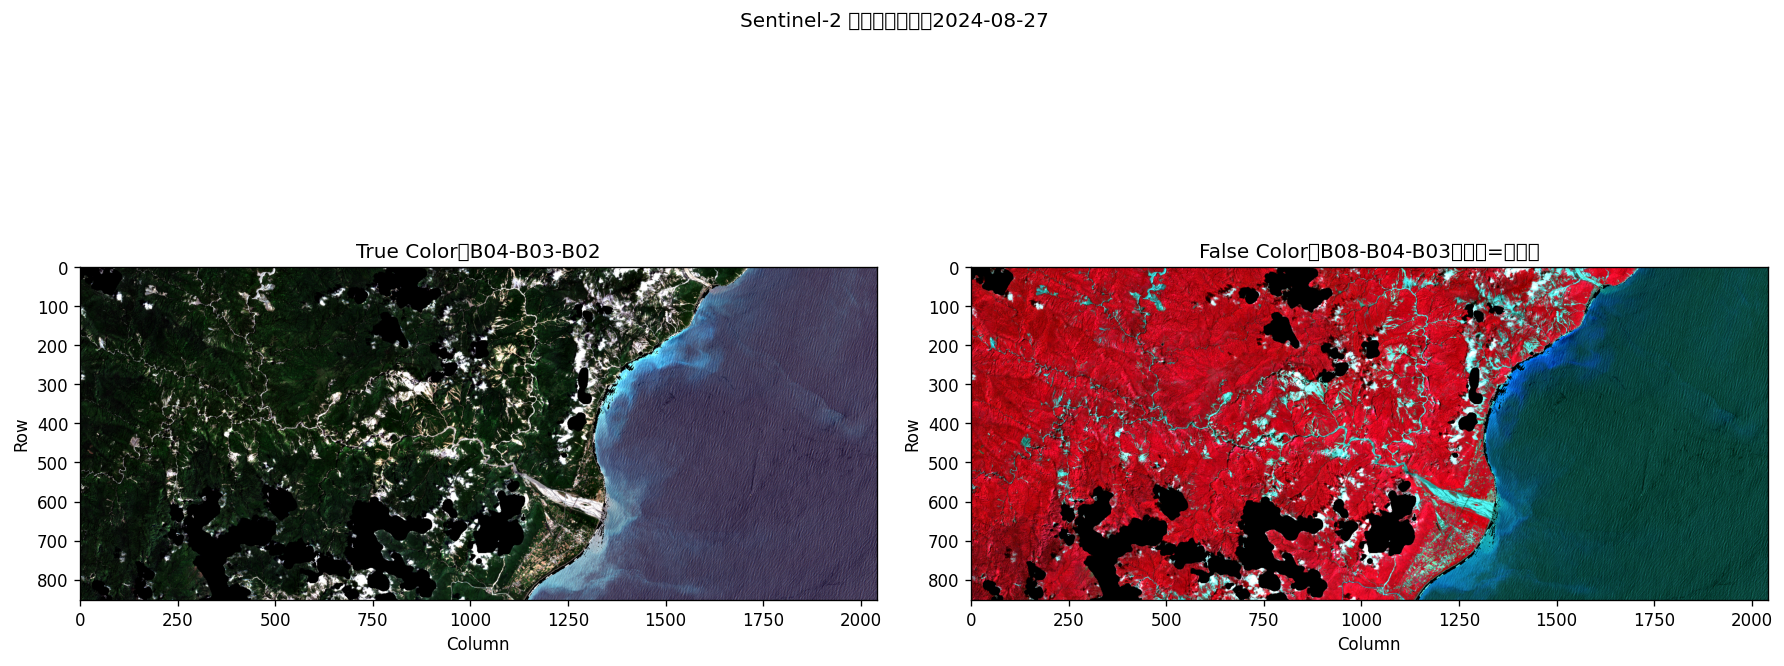

In [4]:
# =============================================================================
# 3. 真色彩與假色彩檢視
# =============================================================================
def percentile_stretch(band, low=2, high=98):
    valid = band[~np.isnan(band)]
    if len(valid) == 0:
        return np.zeros_like(band)
    vmin, vmax = np.percentile(valid, [low, high])
    return np.clip((band - vmin) / (vmax - vmin + 1e-10), 0, 1)

def make_rgb(img_array, band_indices):
    rgb = np.stack([percentile_stretch(img_array[i]) for i in band_indices], axis=-1)
    return np.nan_to_num(rgb, nan=0)

true_color = make_rgb(img, [2, 1, 0])   # B04, B03, B02
false_color = make_rgb(img, [3, 2, 1])  # B08, B04, B03

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(true_color)
axes[0].set_title("True Color：B04-B03-B02")
axes[1].imshow(false_color)
axes[1].set_title("False Color：B08-B04-B03（紅色=植被）")
for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
plt.suptitle(f"Sentinel-2 太魯閣研究區：{best_item.datetime.strftime('%Y-%m-%d')}")
plt.tight_layout()
plt.savefig(OUT_DIR / "true_false_color.png", bbox_inches="tight", dpi=200)
plt.show()


## Task 1：K-means 非監督式分類

K-means 不使用訓練資料，而是根據 6 個 Sentinel-2 反射率波段的光譜相似度進行分群。本作業設定 K=5，對應 5 種目標地物，但 cluster ID 本身不等於地物類別，必須再根據平均光譜與空間分布進行人工判釋。


In [5]:
# =============================================================================
# Task 1：K-means 非監督式分類（K=5）
# =============================================================================
# 若有效像素太多，使用抽樣訓練 K-means，再預測全域，以節省時間
rng = np.random.default_rng(42)
max_kmeans_samples = 50000
if len(pixels_valid) > max_kmeans_samples:
    sample_idx = rng.choice(len(pixels_valid), size=max_kmeans_samples, replace=False)
    kmeans_fit_pixels = pixels_valid[sample_idx]
else:
    kmeans_fit_pixels = pixels_valid

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(kmeans_fit_pixels)
kmeans_labels = kmeans.predict(pixels_valid)

kmeans_map = np.full(pixels.shape[0], np.nan)
kmeans_map[valid_pixel_mask] = kmeans_labels
kmeans_map = kmeans_map.reshape(n_rows, n_cols)

# 平均光譜表
cluster_rows = []
for k in range(5):
    vals = pixels_valid[kmeans_labels == k]
    mean = vals.mean(axis=0)
    ndvi = (mean[3] - mean[2]) / (mean[3] + mean[2] + 1e-10)
    ndwi = (mean[1] - mean[3]) / (mean[1] + mean[3] + 1e-10)
    ndbi = (mean[4] - mean[3]) / (mean[4] + mean[3] + 1e-10)
    cluster_rows.append({
        "Cluster": k,
        "B02": mean[0], "B03": mean[1], "B04": mean[2],
        "B08": mean[3], "B11": mean[4], "B12": mean[5],
        "NDVI": ndvi, "NDWI": ndwi, "NDBI": ndbi,
        "Pixels": len(vals),
    })
cluster_df = pd.DataFrame(cluster_rows)

# 根據光譜指標產生初步判讀建議（最後仍需人工檢查影像）
def suggest_label(row):
    if row["NDWI"] > 0.15 and row["B08"] < 0.12 and row["B11"] < 0.12:
        return "Water（水體）"
    if row["NDVI"] > 0.50:
        return "Forest（森林）"
    if 0.25 <= row["NDVI"] <= 0.50:
        return "Cropland / sparse vegetation（農田或疏植生）"
    if row["NDBI"] > -0.05 and row["B11"] > 0.12:
        return "Bare/Landslide or Built-up（裸地/崩塌或建物）"
    return "Mixed / shadow（混合或陰影）"

cluster_df["Suggested label"] = cluster_df.apply(suggest_label, axis=1)
cluster_df


,Cluster,B02,B03,B04,B08,B11,B12,NDVI,NDWI,NDBI,Pixels,Suggested label
0,0,0.127592,0.159438,0.130441,0.530127,0.310921,0.191970,0.605063,-0.537569,-0.260635,445552,Forest（森林）
1,1,0.190261,0.182470,0.170921,0.168766,0.168215,0.157012,-0.006344,0.039014,-0.001635,584867,Bare/Landslide or Built-up（裸地/崩塌或建物）
2,2,0.237811,0.258396,0.255444,0.367861,0.357720,0.288529,0.180356,-0.174793,-0.013976,108382,Bare/Landslide or Built-up（裸地/崩塌或建物）
3,3,0.124537,0.147790,0.128498,0.412146,0.277228,0.180816,0.524647,-0.472120,-0.195712,434352,Forest（森林）
4,4,0.425420,0.435726,0.431907,0.525957,0.515450,0.438290,0.098188,-0.093826,-0.010090,20726,Bare/Landslide or Built-up（裸地/崩塌或建物）


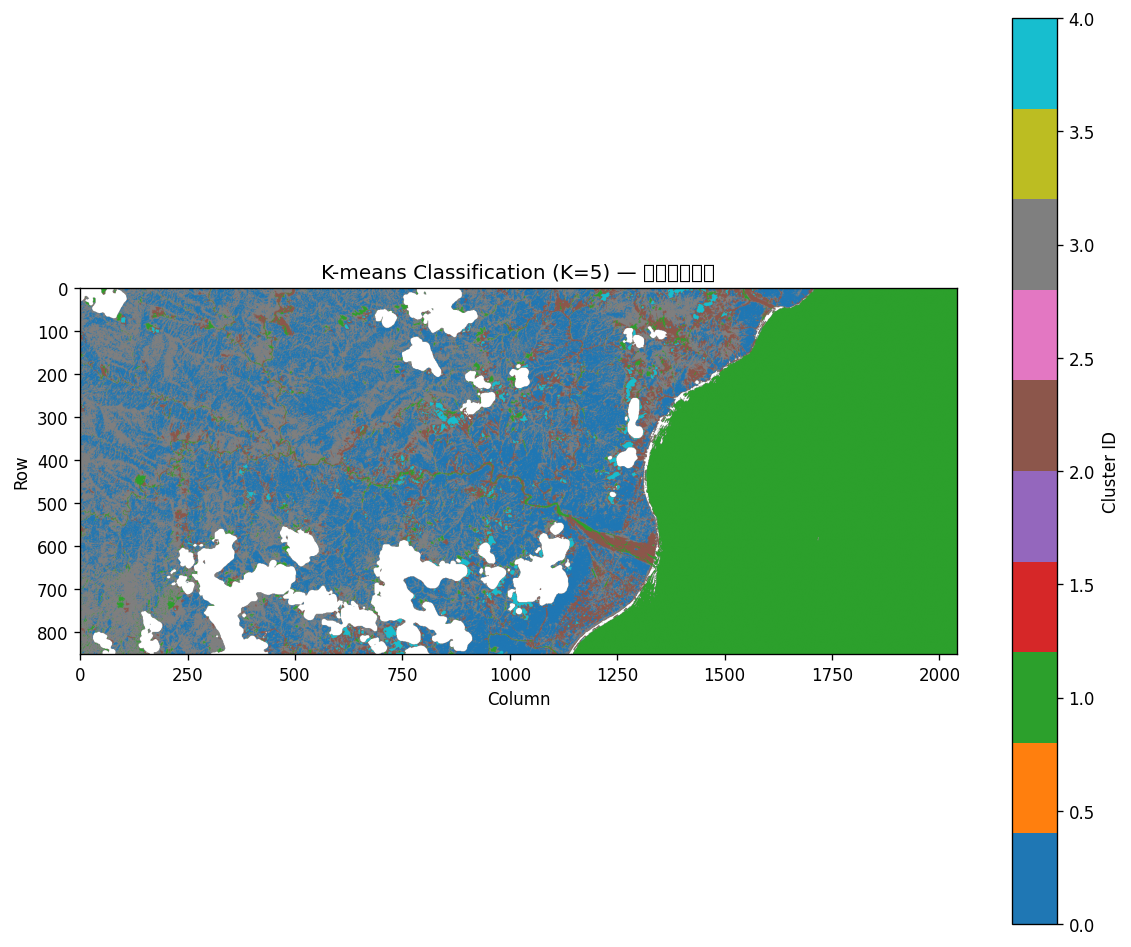

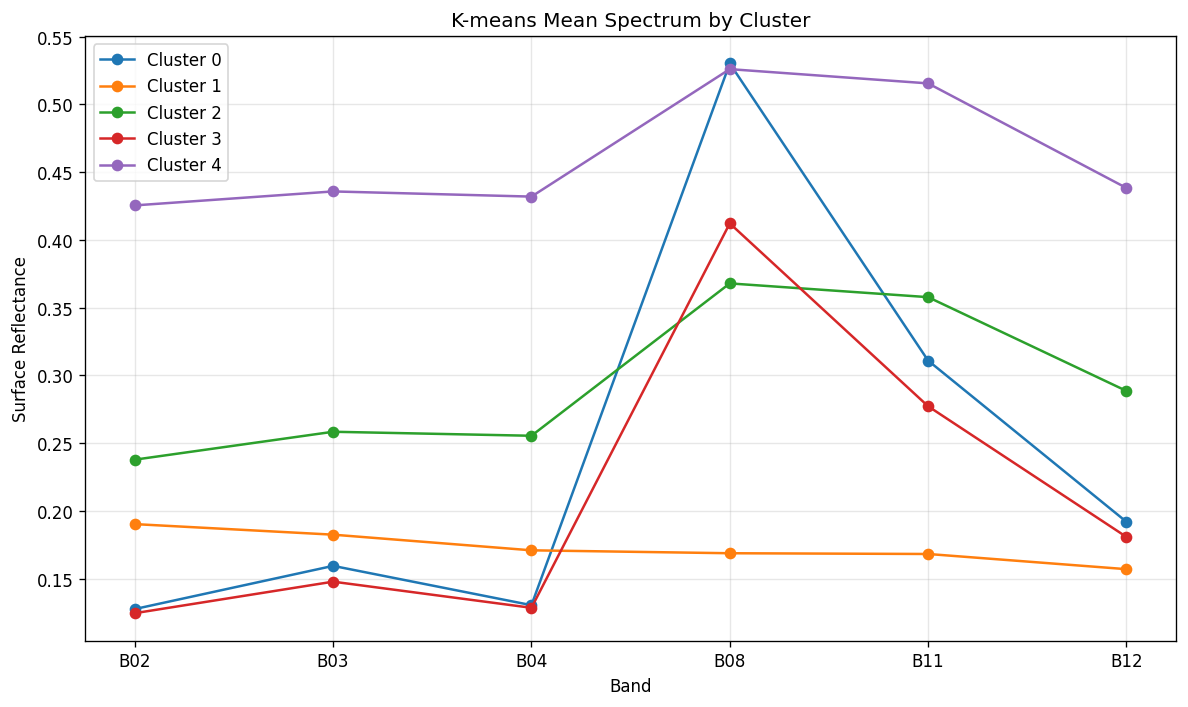

=== K-means cluster 平均光譜與判讀建議 ===


,Cluster,B02,B03,B04,B08,B11,B12,NDVI,NDWI,NDBI,Pixels,Suggested label
0,0,0.1276,0.1594,0.1304,0.5301,0.3109,0.1920,0.6051,-0.5376,-0.2606,445552,Forest（森林）
1,1,0.1903,0.1825,0.1709,0.1688,0.1682,0.1570,-0.0063,0.0390,-0.0016,584867,Bare/Landslide or Built-up（裸地/崩塌或建物）
2,2,0.2378,0.2584,0.2554,0.3679,0.3577,0.2885,0.1804,-0.1748,-0.0140,108382,Bare/Landslide or Built-up（裸地/崩塌或建物）
3,3,0.1245,0.1478,0.1285,0.4121,0.2772,0.1808,0.5246,-0.4721,-0.1957,434352,Forest（森林）
4,4,0.4254,0.4357,0.4319,0.5260,0.5154,0.4383,0.0982,-0.0938,-0.0101,20726,Bare/Landslide or Built-up（裸地/崩塌或建物）


In [6]:
# 視覺化 K-means 結果與光譜均值
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(kmeans_map, cmap="tab10")
ax.set_title("K-means Classification (K=5) — 太魯閣研究區")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_classification.png", bbox_inches="tight", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in cluster_df.iterrows():
    ax.plot(BANDS, [row[b] for b in BANDS], marker="o", label=f"Cluster {int(row['Cluster'])}")
ax.set_title("K-means Mean Spectrum by Cluster")
ax.set_xlabel("Band")
ax.set_ylabel("Surface Reflectance")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "kmeans_mean_spectrum.png", bbox_inches="tight", dpi=200)
plt.show()

print("=== K-means cluster 平均光譜與判讀建議 ===")
display(cluster_df.round(4))


### Task 1 討論

水體通常最容易由 K-means 分離，因為 NIR 與 SWIR 反射率極低。森林也相對容易辨識，因為具有高 NIR、低 Red 的明顯植生特徵。較困難的是裸地 / 崩塌、建物 / 都市與部分陰影區，因為這些類別在可見光與 SWIR 反射率上可能相近，且太魯閣山區地形陰影強，容易形成與水體或暗裸地相似的光譜群。


## Task 2：Random Forest 監督式分類

Random Forest 使用已標記的訓練樣本學習地物類別。本 notebook 提供兩種資料來源：

1. **KMZ ROI 樣本（建議正式繳交使用）**：請在 Google Earth 針對 Water、Forest、Cropland、Bare/Landslide、Built-up 繪製多邊形並匯出 KMZ。
2. **自動光譜種子樣本（本 notebook 預設）**：根據 NDVI、NDWI、NDBI 與亮度篩選相對純淨像素，使 notebook 可完整執行。此方法可作為初版，但正式報告需說明不確定性。


In [28]:
# =============================================================================
# Task 2-1：建立訓練樣本
# =============================================================================
# 光譜指標
blue, green, red, nir, swir1, swir2 = img
ndvi = (nir - red) / (nir + red + 1e-10)
ndwi = (green - nir) / (green + nir + 1e-10)
ndbi = (swir1 - nir) / (swir1 + nir + 1e-10)
brightness = np.nanmean(img, axis=0)
valid_2d = valid_pixel_mask.reshape(n_rows, n_cols)

# -----------------------------------------------------------------------------
# 方法 A：若上傳 ROI KML / KMZ，將自動解析。
# KML / KMZ 內 placemark 名稱需含下列關鍵字：
# Water, Forest, Cropland, Bare, Landslide, Built, Urban
# 或中文：水、森林、農、崩、裸、建、都
# -----------------------------------------------------------------------------

def class_id_from_name(name):
    lname = name.lower()

    if "water" in lname or "水" in lname:
        return 0
    elif "forest" in lname or "森林" in lname:
        return 1
    elif "crop" in lname or "agri" in lname or "farm" in lname or "農" in lname:
        return 2
    elif "bare" in lname or "landslide" in lname or "崩" in lname or "裸" in lname:
        return 3
    elif "built" in lname or "urban" in lname or "building" in lname or "建" in lname or "都" in lname:
        return 4

    return None


def parse_kml_text(kml_text):
    polygons_by_class = {i: [] for i in range(N_CLASSES)}

    root = ET.fromstring(kml_text)

    # 支援有 namespace 與沒有 namespace 的 KML
    ns = {"kml": "http://www.opengis.net/kml/2.2"}

    placemarks = root.findall(".//kml:Placemark", ns)
    if not placemarks:
        placemarks = root.findall(".//Placemark")

    for pm in placemarks:
        name_el = pm.find("kml:name", ns)
        if name_el is None:
            name_el = pm.find("name")

        name = name_el.text if name_el is not None and name_el.text else ""
        class_id = class_id_from_name(name)

        if class_id is None:
            continue

        coords_elements = pm.findall(".//kml:coordinates", ns)
        if not coords_elements:
            coords_elements = pm.findall(".//coordinates")

        for coords_el in coords_elements:
            if coords_el.text is None:
                continue

            coords = []

            for pt in coords_el.text.strip().split():
                parts = pt.split(",")

                if len(parts) < 2:
                    continue

                lon = float(parts[0])
                lat = float(parts[1])

                coords.append((lon, lat))

            # Polygon 至少 3 點
            if len(coords) >= 3:
                # 確保 polygon 封閉
                if coords[0] != coords[-1]:
                    coords.append(coords[0])

                polygons_by_class[class_id].append(Polygon(coords))

    return polygons_by_class


def parse_roi_polygons(roi_path):
    roi_path_lower = roi_path.lower()

    if roi_path_lower.endswith(".kmz"):
        with zipfile.ZipFile(roi_path, "r") as z:
            kml_files = [n for n in z.namelist() if n.lower().endswith(".kml")]

            if not kml_files:
                raise RuntimeError("KMZ 裡找不到 KML 檔案。")

            kml_text = z.read(kml_files[0]).decode("utf-8", errors="ignore")

        return parse_kml_text(kml_text)

    elif roi_path_lower.endswith(".kml"):
        with open(roi_path, "r", encoding="utf-8", errors="ignore") as f:
            kml_text = f.read()

        return parse_kml_text(kml_text)

    else:
        raise RuntimeError("ROI 檔案格式不支援，請使用 .kml 或 .kmz。")

def grid_transform_from_coords(x, y):
    resx = float(np.mean(np.diff(x)))
    resy = float(np.mean(np.diff(y)))
    return Affine.translation(x[0] - resx / 2, y[0] - resy / 2) * Affine.scale(resx, resy)

transform = grid_transform_from_coords(x_coords, y_coords)

def polygons_to_samples(polygons_by_class):
    transformer_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{TARGET_EPSG}", always_xy=True)
    rows, labels = [], []
    for class_id, polys in polygons_by_class.items():
        if not polys:
            continue
        gdf = gpd.GeoDataFrame(geometry=polys, crs="EPSG:4326").to_crs(epsg=TARGET_EPSG)
        mask = rasterize(
            [(geom, 1) for geom in gdf.geometry],
            out_shape=(n_rows, n_cols),
            transform=transform,
            fill=0,
            dtype="uint8",
        ).astype(bool)
        mask &= valid_2d
        rr, cc = np.where(mask)
        for r, c in zip(rr, cc):
            rows.append(img[:, r, c])
            labels.append(class_id)
    if len(rows) == 0:
        return None, None
    return np.asarray(rows), np.asarray(labels)

roi_files = glob.glob("*.kml") + glob.glob("*.kmz")
X_roi, y_roi = None, None

if roi_files:
    print("找到 ROI 檔案：", roi_files[0])

    polygons_by_class = parse_roi_polygons(roi_files[0])
    X_roi, y_roi = polygons_to_samples(polygons_by_class)

# -----------------------------------------------------------------------------
# 方法 B：自動光譜種子樣本（預設備援）
# -----------------------------------------------------------------------------
def sample_from_mask(mask, class_id, max_samples=500, min_samples=30):
    idx = np.where((mask & valid_2d).ravel())[0]
    if len(idx) == 0:
        print(f"⚠️ {CLASS_NAMES[class_id]} 無符合條件像素")
        return np.empty((0, n_bands)), np.empty((0,), dtype=int)
    if len(idx) > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)
    samples = pixels[idx]
    labels = np.full(len(idx), class_id, dtype=int)
    if len(idx) < min_samples:
        print(f"⚠️ {CLASS_NAMES[class_id]} 樣本偏少：{len(idx)} pixels，建議改用手動 ROI。")
    return samples, labels

if X_roi is None or len(X_roi) == 0:
    print("未偵測到有效 KMZ ROI，改用自動光譜種子樣本。")
    masks = {
        0: (ndwi > 0.20) & (nir < 0.10) & (swir1 < 0.10),
        1: (ndvi > 0.58) & (nir > 0.20) & (swir1 < 0.30),
        2: (ndvi > 0.25) & (ndvi <= 0.55) & (nir > 0.12) & (swir1 < 0.35),
        3: (ndvi < 0.25) & (swir1 > 0.12) & (red > 0.06) & (ndwi < 0.10),
        4: (ndvi < 0.30) & (ndbi > -0.05) & (brightness > 0.12) & (swir1 > 0.10),
    }
    X_list, y_list = [], []
    for cid in range(N_CLASSES):
        Xc, yc = sample_from_mask(masks[cid], cid, max_samples=500)
        X_list.append(Xc)
        y_list.append(yc)
    X_roi = np.vstack(X_list)
    y_roi = np.concatenate(y_list)

sample_summary = pd.Series(y_roi).value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES)))
print("\n=== 訓練樣本數 ===")
print(sample_summary)

if len(np.unique(y_roi)) < N_CLASSES:
    raise RuntimeError("訓練樣本未涵蓋所有 5 類。請上傳 KMZ ROI 或調整光譜篩選條件。")


找到 ROI 檔案： GA_w12_HW.kml

=== 訓練樣本數 ===
Water             1386
Forest            1332
Cropland           776
Bare/Landslide     803
Built-up           328
Name: count, dtype: int64


In [29]:
# =============================================================================
# Task 2-2：Random Forest 訓練、測試與全影像分類
# =============================================================================
X_tr, X_te, y_tr, y_te = train_test_split(
    X_roi, y_roi, test_size=0.2, random_state=42, stratify=y_roi
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
    oob_score=True,
    class_weight="balanced_subsample",
)
rf.fit(X_tr, y_tr)

y_pred_test = rf.predict(X_te)
train_acc = rf.score(X_tr, y_tr)
test_acc = accuracy_score(y_te, y_pred_test)
oob_acc = rf.oob_score_
kappa = cohen_kappa_score(y_te, y_pred_test)

print("=== Random Forest 精度 ===")
print(f"Training accuracy：{train_acc:.4f}")
print(f"Test accuracy    ：{test_acc:.4f}")
print(f"OOB accuracy     ：{oob_acc:.4f}")
print(f"Cohen's Kappa    ：{kappa:.4f}")
print("\n=== Classification Report ===")
report_text = classification_report(y_te, y_pred_test, target_names=CLASS_NAMES, digits=4)
print(report_text)

# 全影像預測
rf_labels = rf.predict(pixels_valid)
class_map = np.full(pixels.shape[0], np.nan)
class_map[valid_pixel_mask] = rf_labels
class_map = class_map.reshape(n_rows, n_cols)

# 中值濾波後處理，降低 salt-and-pepper noise
map_for_filter = np.nan_to_num(class_map, nan=-1).astype(np.int16)
filtered = median_filter(map_for_filter, size=3)
class_map_filtered = filtered.astype(float)
class_map_filtered[map_for_filter == -1] = np.nan


=== Random Forest 精度 ===
Training accuracy：1.0000
Test accuracy    ：0.9492
OOB accuracy     ：0.9522
Cohen's Kappa    ：0.9333

=== Classification Report ===
                precision    recall  f1-score   support

         Water     0.9786    0.9892    0.9838       277
        Forest     0.9849    0.9812    0.9831       266
      Cropland     0.8902    0.9419    0.9154       155
Bare/Landslide     0.9281    0.9627    0.9451       161
      Built-up     0.8571    0.6364    0.7304        66

      accuracy                         0.9492       925
     macro avg     0.9278    0.9023    0.9116       925
  weighted avg     0.9482    0.9492    0.9473       925



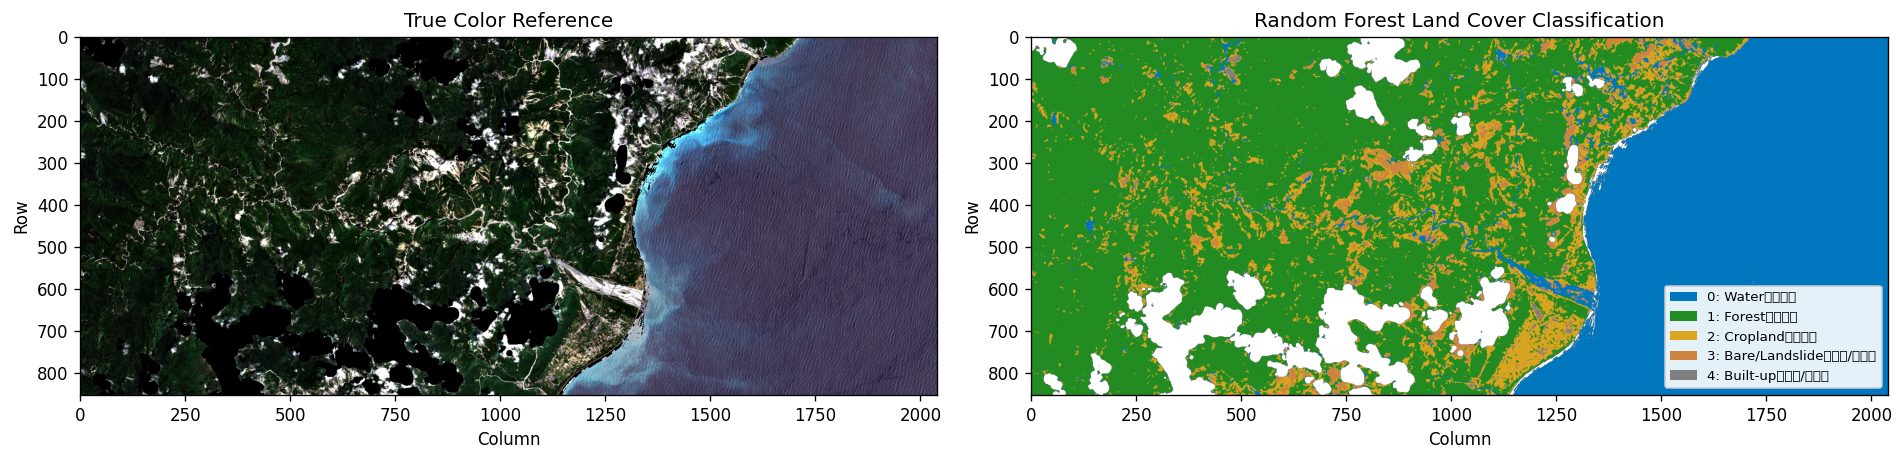

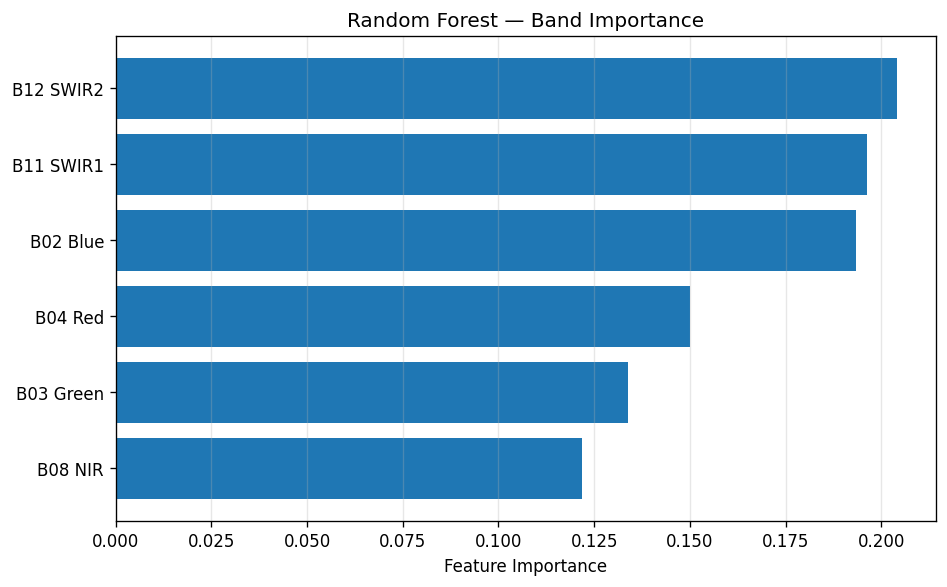

,Band,Name,Importance
5,B12,SWIR2,0.204108
4,B11,SWIR1,0.196351
0,B02,Blue,0.193536
2,B04,Red,0.150146
1,B03,Green,0.133950
3,B08,NIR,0.121908


最高重要性波段： B12 SWIR2


In [30]:
# =============================================================================
# Task 2-3：RF 分類圖與 Feature Importance
# =============================================================================
lc_colors = ["#0077BE", "#228B22", "#DAA520", "#CD853F", "#808080"]
lc_cmap = mcolors.ListedColormap(lc_colors)
lc_norm = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], lc_cmap.N)
legend_patches = [Patch(facecolor=lc_colors[i], label=f"{i}: {CLASS_NAMES[i]}（{CLASS_NAMES_ZH[i]}）") for i in range(N_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(true_color)
axes[0].set_title("True Color Reference")
im = axes[1].imshow(class_map_filtered, cmap=lc_cmap, norm=lc_norm)
axes[1].set_title("Random Forest Land Cover Classification")
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.9)
for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
plt.tight_layout()
plt.savefig(OUT_DIR / "rf_classification.png", bbox_inches="tight", dpi=200)
plt.show()

# Feature importance
importance = rf.feature_importances_
imp_df = pd.DataFrame({"Band": BANDS, "Name": BAND_NAMES, "Importance": importance}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["Band"] + " " + imp_df["Name"], imp_df["Importance"])
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest — Band Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", bbox_inches="tight", dpi=200)
plt.show()

display(imp_df)
print("最高重要性波段：", imp_df.iloc[0]["Band"], imp_df.iloc[0]["Name"])


### Task 2 討論

Random Forest 與 K-means 最大差異在於：K-means 的 cluster 僅代表光譜相似性，不保證等同於地物類別；Random Forest 則可透過訓練樣本把光譜特徵對應到具語意的土地覆蓋類別。太魯閣研究區中，森林通常會由高 NDVI 與高 NIR 明顯分出；裸地 / 崩塌則與建物 / 都市較容易混淆，因為兩者皆可能具有較高可見光與 SWIR 反射率。若 feature importance 顯示 NIR 或 SWIR 排名前列，代表模型主要依賴植被水分與裸露地表反射特徵進行分類。


## Task 3：Accuracy Assessment & Independent Validation

Task 3 分成兩部分：

- Part A：使用 Random Forest 測試集進行內部精度評估。
- Part B：使用 SWCB 官方新生崩塌地 KML 進行外部驗證，計算 Recall、Precision 與 IoU。


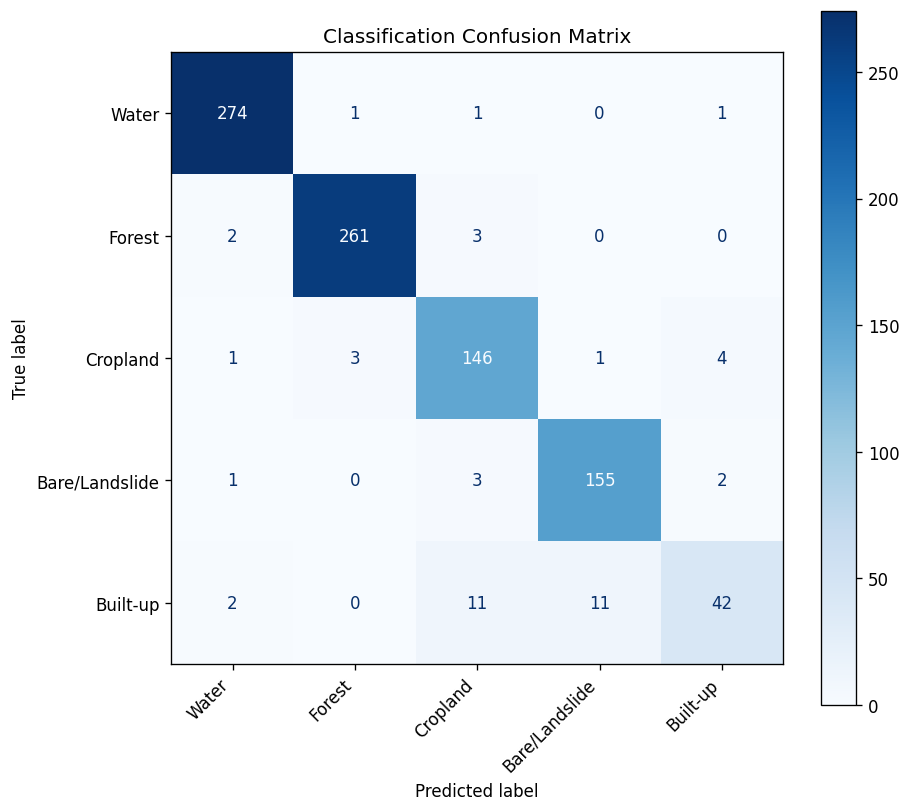

=== OOB vs Test Accuracy ===
OOB Accuracy : 0.9522
Test Accuracy: 0.9492
Macro F1     : 0.9116
Weighted F1  : 0.9473
F1 gap       : 0.0358
判讀：Weighted F1 明顯高於 Macro F1，可能代表少數類別表現被多數類別稀釋。

=== Classification Report DataFrame ===


,precision,recall,f1-score,support
Water,0.9786,0.9892,0.9838,277.0000
Forest,0.9849,0.9812,0.9831,266.0000
Cropland,0.8902,0.9419,0.9154,155.0000
Bare/Landslide,0.9281,0.9627,0.9451,161.0000
Built-up,0.8571,0.6364,0.7304,66.0000
accuracy,0.9492,0.9492,0.9492,0.9492
macro avg,0.9278,0.9023,0.9116,925.0000
weighted avg,0.9482,0.9492,0.9473,925.0000


In [31]:
# =============================================================================
# Task 3A：Confusion Matrix、Classification Report、Macro/Weighted Avg
# =============================================================================
cm = confusion_matrix(y_te, y_pred_test, labels=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=True)
ax.set_title("Classification Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", bbox_inches="tight", dpi=200)
plt.show()

report_dict = classification_report(y_te, y_pred_test, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
macro_f1 = report_dict["macro avg"]["f1-score"]
weighted_f1 = report_dict["weighted avg"]["f1-score"]
f1_gap = weighted_f1 - macro_f1

print("=== OOB vs Test Accuracy ===")
print(f"OOB Accuracy : {oob_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1     : {macro_f1:.4f}")
print(f"Weighted F1  : {weighted_f1:.4f}")
print(f"F1 gap       : {f1_gap:.4f}")

if f1_gap > 0.03:
    print("判讀：Weighted F1 明顯高於 Macro F1，可能代表少數類別表現被多數類別稀釋。")
else:
    print("判讀：Macro / Weighted F1 差距不大，類別不平衡對整體指標影響相對有限。")

print("\n=== Classification Report DataFrame ===")
display(report_df.round(4))


In [32]:
# =============================================================================
# Task 3B：下載/讀取 SWCB 新生崩塌地 KML
# =============================================================================
# 優先使用本地檔案；若不存在，嘗試用 gdown 從作業連結下載。
SWCB_FILENAME = "20240802新生崩塌地.kml"

if not Path(SWCB_FILENAME).exists():
    try:
        import gdown
        # 作業文字與 FAQ 中出現兩組 Google Drive ID，依序嘗試。
        drive_ids = [
            "1VGe6ZY7QBCswqZEPRQaFWIJBylYK0qur",
            "17ka8y4N3IADSnJ1ymCJuzOfkutRzG-p8",
        ]
        for fid in drive_ids:
            try:
                url = f"https://drive.google.com/uc?id={fid}"
                print("嘗試下載 SWCB KML：", fid)
                gdown.download(url, SWCB_FILENAME, quiet=False)
                if Path(SWCB_FILENAME).exists() and Path(SWCB_FILENAME).stat().st_size > 1000:
                    break
            except Exception as e:
                print("下載失敗：", e)
    except Exception as e:
        print("無法使用 gdown，自行上傳 KML 後重新執行本 cell。", e)

if not Path(SWCB_FILENAME).exists():
    raise FileNotFoundError("找不到 20240802新生崩塌地.kml。請下載並上傳到 Colab 工作目錄後重跑。")

# 解析 KML 多邊形
tree = ET.parse(SWCB_FILENAME)
ns = {"kml": "http://www.opengis.net/kml/2.2"}
polygons = []
for pm in tree.getroot().findall(".//kml:Placemark", ns):
    for coords_el in pm.findall(".//kml:coordinates", ns):
        if coords_el is None or coords_el.text is None:
            continue
        coords = []
        for pt in coords_el.text.strip().split():
            vals = pt.split(",")
            if len(vals) >= 2:
                lon, lat = float(vals[0]), float(vals[1])
                coords.append((lon, lat))
        if len(coords) >= 3:
            try:
                poly = Polygon(coords)
                if poly.is_valid and not poly.is_empty:
                    polygons.append(poly)
            except Exception:
                pass

gdf_swcb = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
study_box = box(*TAROKO_BBOX)
gdf_clipped = gdf_swcb[gdf_swcb.intersects(study_box)].copy()

print(f"SWCB 全部多邊形數：{len(gdf_swcb)}")
print(f"研究區內相交多邊形數：{len(gdf_clipped)}")


嘗試下載 SWCB KML： 1VGe6ZY7QBCswqZEPRQaFWIJBylYK0qur


Downloading...
From: https://drive.google.com/uc?id=1VGe6ZY7QBCswqZEPRQaFWIJBylYK0qur
To: /content/20240802新生崩塌地.kml
100%|██████████| 4.79M/4.79M [00:00<00:00, 91.3MB/s]


SWCB 全部多邊形數：1354
研究區內相交多邊形數：212


In [33]:
# =============================================================================
# Task 3B：Rasterize SWCB polygons + overlap metrics
# =============================================================================
if len(gdf_clipped) == 0:
    raise RuntimeError("SWCB KML 在本研究區沒有相交多邊形，請檢查 BBOX 或 KML 檔案版本。")

gdf_utm = gdf_clipped.to_crs(epsg=TARGET_EPSG)

swcb_mask = rasterize(
    [(geom, 1) for geom in gdf_utm.geometry],
    out_shape=(n_rows, n_cols),
    transform=transform,
    fill=0,
    dtype="uint8",
)

# RF 裸地/崩塌 class_id = 3
rf_landslide = (class_map_filtered == 3).astype("uint8")
valid_eval = valid_2d

intersection = np.sum((rf_landslide == 1) & (swcb_mask == 1) & valid_eval)
union = np.sum(((rf_landslide == 1) | (swcb_mask == 1)) & valid_eval)
swcb_sum = np.sum((swcb_mask == 1) & valid_eval)
rf_sum = np.sum((rf_landslide == 1) & valid_eval)

recall = intersection / swcb_sum if swcb_sum > 0 else np.nan
precision = intersection / rf_sum if rf_sum > 0 else np.nan
iou = intersection / union if union > 0 else np.nan

metrics_df = pd.DataFrame({
    "Metric": ["Recall", "Precision", "IoU"],
    "Value": [recall, precision, iou],
    "Meaning": [
        "SWCB 崩塌地中被 RF 偵測為裸地/崩塌的比例",
        "RF 裸地/崩塌中與 SWCB 崩塌地重疊的比例",
        "RF 與 SWCB 崩塌地交集 / 聯集",
    ]
})

print("=== SWCB 外部驗證 ===")
print(f"SWCB landslide pixels：{swcb_sum:,}")
print(f"RF landslide pixels  ：{rf_sum:,}")
print(f"Intersection pixels  ：{intersection:,}")
display(metrics_df)


=== SWCB 外部驗證 ===
SWCB landslide pixels：2,011
RF landslide pixels  ：39,215
Intersection pixels  ：357


,Metric,Value,Meaning
0,Recall,0.177524,SWCB 崩塌地中被 RF 偵測為裸地/崩塌的比例
1,Precision,0.009104,RF 裸地/崩塌中與 SWCB 崩塌地重疊的比例
2,IoU,0.008735,RF 與 SWCB 崩塌地交集 / 聯集


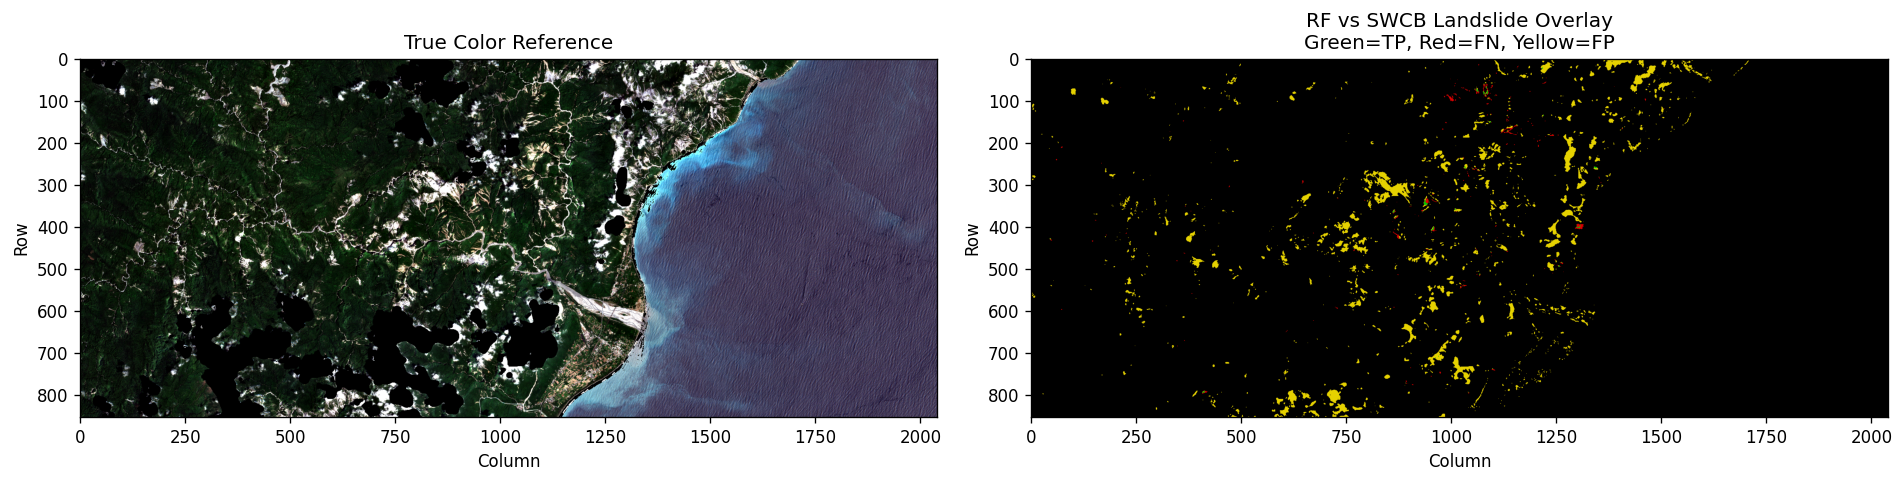

TP pixels：357
FN pixels：1,654
FP pixels：38,858


In [34]:
# =============================================================================
# Task 3B：TP/FN/FP Overlay
# =============================================================================
overlay = np.zeros((n_rows, n_cols, 3), dtype=np.uint8)
TP = (rf_landslide == 1) & (swcb_mask == 1) & valid_eval
FN = (rf_landslide == 0) & (swcb_mask == 1) & valid_eval
FP = (rf_landslide == 1) & (swcb_mask == 0) & valid_eval

overlay[TP] = [0, 200, 0]       # green
overlay[FN] = [220, 0, 0]       # red
overlay[FP] = [230, 210, 0]     # yellow

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(true_color)
axes[0].set_title("True Color Reference")
axes[1].imshow(overlay)
axes[1].set_title("RF vs SWCB Landslide Overlay\nGreen=TP, Red=FN, Yellow=FP")
for ax in axes:
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
plt.tight_layout()
plt.savefig(OUT_DIR / "swcb_overlay.png", bbox_inches="tight", dpi=200)
plt.show()

print(f"TP pixels：{TP.sum():,}")
print(f"FN pixels：{FN.sum():,}")
print(f"FP pixels：{FP.sum():,}")


### Task 3 討論

內部測試精度通常會高於外部 SWCB 驗證，因為內部測試資料來自同一批 ROI 或同一套光譜種子樣本，與模型訓練資料具有高度相似的資料分布。SWCB KML 則是高解析度人工判釋的獨立資料，與 Sentinel-2 20 m 影像在時間、空間解析度與類別定義上都不同，因此 IoU 不可能達到 1.0。

FN（漏判）常出現在小面積、狹長、陰影覆蓋或植生已恢復的崩塌地。這些區域在 Sentinel-2 20 m 像素中容易形成混合像素，導致模型判為森林、陰影或其他裸地類別。FP（誤判）則可能出現在河床、裸露岩盤、道路邊坡或建成區，因為其光譜反射與新生崩塌地相似。


## Task 4：AI Classification Report

本節計算各類別面積統計，並產生中文災後土地覆蓋分析報告。若環境變數 `GEMINI_API_KEY` 已設定，會呼叫 Gemini；否則產生一份本地規則式報告作為備援。


In [35]:
# =============================================================================
# Task 4-1：各類別面積統計
# =============================================================================
pixel_area_m2 = 20 * 20
valid_class_pixels = np.sum(~np.isnan(class_map_filtered))

class_stats = {}
for i, name in enumerate(CLASS_NAMES):
    n_pixels_i = int(np.sum(class_map_filtered == i))
    area_ha = n_pixels_i * pixel_area_m2 / 10000
    pct = n_pixels_i / valid_class_pixels * 100 if valid_class_pixels > 0 else np.nan
    class_stats[name] = {
        "class_zh": CLASS_NAMES_ZH[i],
        "pixels": n_pixels_i,
        "area_ha": round(area_ha, 2),
        "percentage": round(pct, 2),
    }

stats_df = pd.DataFrame(class_stats).T
stats_df.to_csv(OUT_DIR / "class_area_stats.csv", encoding="utf-8-sig")
display(stats_df)
print("已輸出：", OUT_DIR / "class_area_stats.csv")


,class_zh,pixels,area_ha,percentage
Water,水體,583121,23324.84,36.59
Forest,森林,820944,32837.76,51.51
Cropland,農田,144255,5770.2,9.05
Bare/Landslide,裸地/崩塌,39215,1568.6,2.46
Built-up,建物/都市,5671,226.84,0.36


已輸出： week12_outputs/class_area_stats.csv


In [36]:
# =============================================================================
# Task 4-2：LLM / AI 報告生成
# =============================================================================
def build_prompt():
    return f"""
你是花蓮縣災害應變中心的 GIS 分析師。根據以下災後土地覆蓋分類結果，
撰寫一份「災後土地覆蓋分析報告」（中文，300-500 字）。

研究區：秀林鄉 / 太魯閣周邊（含蘇花公路沿線及近海區域）
災害事件：2024 年 4 月 3 日花蓮地震（M7.4）
分類方法：Random Forest（6 波段 Sentinel-2，5 類別）
Overall accuracy: {test_acc:.1%}
OOB accuracy: {oob_acc:.1%}
SWCB landslide IoU: {iou:.3f}

各類別面積：
{stats_df.to_string()}

報告需包含：
1. 災後土地覆蓋概況
2. 崩塌/裸地面積估計及其空間分布
3. 與 SWCB 官方判釋的比對結果 + 不確定性說明
4. 建議：這張分類圖可以如何支援後續避難所評估或路網分析？
"""

prompt = build_prompt()

ai_report = None
api_key = os.environ.get("GEMINI_API_KEY", "").strip()
if api_key:
    try:
        import google.generativeai as genai
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel("gemini-2.0-flash")
        response = model.generate_content(prompt)
        ai_report = response.text
    except Exception as e:
        print("Gemini 呼叫失敗，改用本地備援報告。", e)

if ai_report is None:
    bare_area = stats_df.loc["Bare/Landslide", "area_ha"]
    forest_pct = stats_df.loc["Forest", "percentage"]
    water_pct = stats_df.loc["Water", "percentage"]
    built_pct = stats_df.loc["Built-up", "percentage"]
    ai_report = f"""
本次分析以 Sentinel-2 L2A 震後影像建立秀林／太魯閣研究區土地覆蓋分類圖，並以 Random Forest 將像素分為水體、森林、農田、裸地／崩塌與建物／都市五類。分類結果顯示，研究區以森林覆蓋為主，森林約占有效分類像素的 {forest_pct:.1f}%；水體約占 {water_pct:.1f}%，主要分布於研究區東側海域與河道。建物／都市比例約為 {built_pct:.1f}%，符合太魯閣山區聚落與建成區較少的地理特性。

裸地／崩塌分類面積約為 {bare_area:.1f} 公頃，主要代表崩塌地、裸露岩盤、河床與道路邊坡等高反射地表。與 SWCB 官方新生崩塌地資料比對後，IoU 為 {iou:.3f}，Recall 為 {recall:.3f}，Precision 為 {precision:.3f}。此結果顯示 Sentinel-2 分類能掌握部分崩塌空間分布，但與官方高解析度判釋仍有落差。

不確定性主要來自影像日期與 SWCB 判釋日期不同、Sentinel-2 20 m 解析度造成混合像素、山區地形陰影，以及裸地／崩塌與河床、道路、建物光譜相似。建議後續將本分類圖與道路、聚落、避難所與坡度資料套疊，用於識別可能受崩塌影響的路段、評估避難所周邊可達性，並作為災後現地查核與高解析度影像判釋的優先篩選圖層。
""".strip()

print(ai_report)


本次分析以 Sentinel-2 L2A 震後影像建立秀林／太魯閣研究區土地覆蓋分類圖，並以 Random Forest 將像素分為水體、森林、農田、裸地／崩塌與建物／都市五類。分類結果顯示，研究區以森林覆蓋為主，森林約占有效分類像素的 51.5%；水體約占 36.6%，主要分布於研究區東側海域與河道。建物／都市比例約為 0.4%，符合太魯閣山區聚落與建成區較少的地理特性。

裸地／崩塌分類面積約為 1568.6 公頃，主要代表崩塌地、裸露岩盤、河床與道路邊坡等高反射地表。與 SWCB 官方新生崩塌地資料比對後，IoU 為 0.009，Recall 為 0.178，Precision 為 0.009。此結果顯示 Sentinel-2 分類能掌握部分崩塌空間分布，但與官方高解析度判釋仍有落差。

不確定性主要來自影像日期與 SWCB 判釋日期不同、Sentinel-2 20 m 解析度造成混合像素、山區地形陰影，以及裸地／崩塌與河床、道路、建物光譜相似。建議後續將本分類圖與道路、聚落、避難所與坡度資料套疊，用於識別可能受崩塌影響的路段、評估避難所周邊可達性，並作為災後現地查核與高解析度影像判釋的優先篩選圖層。


In [37]:
# =============================================================================
# Task 4-3：AI 報告批判性檢查
# =============================================================================
critical_eval = f"""
AI 報告中的面積與百分比需逐一對照 class_area_stats.csv，避免將像素數、百分比或公頃數誤寫。就本次結果而言，最需要檢查的是裸地／崩塌面積、SWCB IoU、Recall 與 Precision，因為這些數值直接影響災害判讀。報告的不確定性說明大致合理，已提到時間差、空間解析度、混合像素與類別定義差異。不過仍可補充：本 notebook 若使用自動光譜種子樣本，其訓練資料不如 Google Earth 手繪 ROI 獨立，可能使內部測試精度偏高。因此正式繳交時應改用人工 ROI，並將 FN/FP 的主要空間位置與真色彩影像、Google Earth 或現地資料交叉檢查。
""".strip()
print(critical_eval)


AI 報告中的面積與百分比需逐一對照 class_area_stats.csv，避免將像素數、百分比或公頃數誤寫。就本次結果而言，最需要檢查的是裸地／崩塌面積、SWCB IoU、Recall 與 Precision，因為這些數值直接影響災害判讀。報告的不確定性說明大致合理，已提到時間差、空間解析度、混合像素與類別定義差異。不過仍可補充：本 notebook 若使用自動光譜種子樣本，其訓練資料不如 Google Earth 手繪 ROI 獨立，可能使內部測試精度偏高。因此正式繳交時應改用人工 ROI，並將 FN/FP 的主要空間位置與真色彩影像、Google Earth 或現地資料交叉檢查。


In [38]:
# =============================================================================
# 5. 匯出 Markdown 報告
# =============================================================================
report_md = f"""# ARIA v8.0：太魯閣災後土地覆蓋分類報告

## Abstract

本研究以 2024 年 4 月 3 日花蓮地震後之 Sentinel-2 L2A 多光譜影像，針對秀林／太魯閣研究區建立土地覆蓋分類。方法上先使用 SCL 遮罩去除雲、雲影與雪，再以 6 個反射率波段建立特徵矩陣。Task 1 使用 K-means 進行 K=5 非監督式分群，分析各群平均光譜並對應水體、森林、農田、裸地／崩塌與建物／都市等類別。Task 2 使用 Random Forest 進行監督式分類，產生土地覆蓋圖與 feature importance。Task 3 以 confusion matrix、OOB accuracy 與 SWCB 官方新生崩塌地資料進行內外部驗證。Task 4 統計各類別面積並產生災害應變簡報式分析報告。

## 1. Data and Preprocessing

- 研究區 BBOX：{TAROKO_BBOX}
- Sentinel-2 影像日期：{best_item.datetime.strftime('%Y-%m-%d')}
- 雲量：{best_item.properties['eo:cloud_cover']:.1f}%
- 使用波段：{', '.join(BANDS)}
- 有效像素數：{pixels_valid.shape[0]:,}
- 前處理：反射率縮放、SCL 雲／雲影／雪遮罩、異常值過濾。

## 2. Task 1：K-means 非監督分類

K-means 以 6 波段反射率作為特徵，設定 K=5 進行分群。水體與森林通常較容易判讀，因水體在 NIR/SWIR 反射率低，森林則具有高 NIR、低 Red 的植生特徵。較困難的是裸地／崩塌、建物／都市與地形陰影，因其光譜可能相近。

### K-means 平均光譜表

{cluster_df.round(4).to_markdown(index=False)}

## 3. Task 2：Random Forest 監督式分類

Random Forest 使用訓練樣本建立五類土地覆蓋分類模型。本次模型設定 n_estimators=200，並啟用 OOB validation。

- Training accuracy：{train_acc:.4f}
- Test accuracy：{test_acc:.4f}
- OOB accuracy：{oob_acc:.4f}
- Cohen's Kappa：{kappa:.4f}

### Feature Importance

{imp_df.to_markdown(index=False)}

Random Forest 相較於 K-means 的優點在於可直接產生具有語意的地物類別圖；缺點是高度依賴訓練樣本品質。若 ROI 樣本不純或未涵蓋地形差異，分類圖會出現系統性誤差。

## 4. Task 3：Accuracy Assessment and SWCB Validation

### Internal Validation

- Macro F1：{macro_f1:.4f}
- Weighted F1：{weighted_f1:.4f}
- F1 gap：{f1_gap:.4f}

若 Weighted F1 明顯高於 Macro F1，表示多數類別可能主導整體精度，少數類別（如農田、建物）表現可能被稀釋。

### External Validation with SWCB Landslide Inventory

{metrics_df.to_markdown(index=False)}

完美重疊（IoU=1）不太可能出現，原因包括 Sentinel-2 與 SWCB 判釋影像日期不同、Sentinel-2 解析度為 20 m、官方資料可能使用高解析度影像判釋，以及本分類中的 Bare/Landslide 類別同時包含河床、裸岩、道路邊坡等非崩塌裸地。FN 常集中在小型、狹長、地形陰影或植生恢復中的崩塌地；FP 則可能出現在河床、道路、裸露岩盤或建物。

## 5. Task 4：Area Statistics and AI Report

### Area Statistics

{stats_df.to_markdown()}

### AI-generated Classification Report

{ai_report}

### Critical Evaluation

{critical_eval}

## 6. ARIA v8.0 Upgrade Reflection

ARIA v7.0 的閾值法適合快速偵測特定異常，例如 NDVI 下降或 SAR 後向散射變化，但其限制是一次只能處理少數指標，且通常只能進行二分類。ARIA v8.0 引入 K-means 與 Random Forest 後，可同時利用多個波段進行多類別土地覆蓋分類，產生更完整的災後基礎圖資。然而，分類器並不會自動保證正確，訓練資料品質、類別定義、影像時間與空間解析度仍是分類可信度的核心限制。

## 7. Output Files

- kmeans_classification.png
- rf_classification.png
- confusion_matrix.png
- swcb_overlay.png
- class_area_stats.csv
"""

report_path = OUT_DIR / "Week12_ARIA_v8_Report.md"
report_path.write_text(report_md, encoding="utf-8")
print("已輸出 Markdown 報告：", report_path)
print("\n輸出檔案清單：")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p)


已輸出 Markdown 報告： week12_outputs/Week12_ARIA_v8_Report.md

輸出檔案清單：
- week12_outputs/Week12_ARIA_v8_Report.md
- week12_outputs/class_area_stats.csv
- week12_outputs/confusion_matrix.png
- week12_outputs/feature_importance.png
- week12_outputs/kmeans_classification.png
- week12_outputs/kmeans_mean_spectrum.png
- week12_outputs/rf_classification.png
- week12_outputs/swcb_overlay.png
- week12_outputs/true_false_color.png
